Hello Deena, welcome to my notebook showcasing my automl library. If you are interested you can look at the diagram in the chat.

The goal of the program is that the user can easily use advanced predifined or custom hypertuning and feature selection methods on their dataset.

The user needs to supply the target column as a string, the dataset as a df, as well as either choose from the predifined hypertuning and feature selection methods or make their own which uphold a interface.

The run_automl method first runs the feature selection function if defined. then the hypertuning method if defined.



In [4]:

import sys
import pandas as pd
from pathlib import Path

#the import process will be different if made like a true library
code = Path.cwd()/'code'
sys.path.append(str(code))
from automl.automl import SimpleAutoML
from Loss import mae, mape
from feature_selection.forward import ForwardFeatureSelector
from feature_selection.backwards import BackwardFeatureSelector  
from hyper_tuning import GridSearchTuner, RandomSearchTuner, LineSearchTuner  


In [2]:

data_path='cleaned_data_harsh.csv'

df=pd.read_csv(data_path)
df=df.sample(frac=0.05, random_state=42) #5 percent of the data

df_clean=df.drop(columns=['dato'])
print(f"data shape {df_clean.shape}")

automl=SimpleAutoML()


data shape (76117, 21)
Failed to load model from /Users/victor/School/bachelor 2/bachelor/automltrainer/code/models/lightgbm.py: No module named 'lightgbm'
Registered model: linear_regression
Registered model: xgboost


In [3]:
# a simple run through with no feature selection and no hyperparameter tuning

results = automl.run_automl( df=df_clean,
    target_col='Købesum', # target column
    feature_selection_fn=None, # how you specify no feature selection
    models_to_run=['linear_regression', 'xgboost'], # models we would like to include if we dont supply this then all valid models are chosen
    hypertuning_fn=None, # how you specify no hyperparameter tuning
    loss_fn=mae(), # loss function to use
    n_splits=5, # number of splits for cross-validation i use scikitlearn time series split
    test_split=0.1) # percentage of the data to use for testing

Data split - Train: 68505, Test: 7612
Training 2 models: ['linear_regression', 'xgboost']

Training linear_regression
  Using default parameters for linear_regression
linear_regression - Test mae: 1196648.85 (Features: 20)

Training xgboost
  Using default parameters for xgboost
xgboost - Test mae: 916447.56 (Features: 20)

AUTOML RESULTS
linear_regression: Test mae: 1,196,648.85
xgboost: Test mae: 916,447.56

Best Model: xgboost
Best Test mae: 916,447.56


In [4]:

save_path = automl.save_model('saved_models/Deenaexample1') # how we can save the model and specification like the scalar and columns we used

Model package saved to: saved_models/Deenaexample1.pkl
Model weights saved to: saved_models/Deenaexample1_xgboost.json


In [5]:
# example with feature selection
results = automl.run_automl( df=df_clean,
    target_col='Købesum',
    feature_selection_fn=ForwardFeatureSelector,
    models_to_run=[ 'xgboost','linear_regression',],
    hypertuning_fn=None,
    loss_fn=mae(),
    n_splits=5,
    test_split=0.1)

Data split - Train: 68505, Test: 7612
Training 2 models: ['xgboost', 'linear_regression']

Training xgboost
  Running feature selection for xgboost
Starting forward feature selection with 20 available features
Added feature: mean_of_5_neighbors_pris, CV Score: 1075762.0250, Selected: 1
Added feature: pris_pr_m2_mean_365D_by, CV Score: 1027584.5375, Selected: 2
Added feature: age, CV Score: 999343.1250, Selected: 3
Added feature: m2, CV Score: 967741.4000, Selected: 4
Added feature: std_of_5_neighbors_pris_pr_m2, CV Score: 954004.0000, Selected: 5
Added feature: btype_Villa, CV Score: 942266.4750, Selected: 6
Added feature: btype_Fritidshus, CV Score: 935464.4250, Selected: 7
Added feature: omr_de_Hovedstaden__K_benhavn, CV Score: 930185.6000, Selected: 8
Added feature: date_ordinal, CV Score: 923547.8750, Selected: 9
Added feature: btype_R_kkehus, CV Score: 921699.9375, Selected: 10
Added feature: omr_de_Nordsj_lland, CV Score: 919865.1375, Selected: 11
Added feature: omr_de_Sydjylland

In [6]:
# another type of feature selection, cool huh? 

results = automl.run_automl( df=df_clean,
    target_col='Købesum',
    feature_selection_fn=BackwardFeatureSelector,
    models_to_run=[ 'xgboost','linear_regression',],
    hypertuning_fn=None,
    loss_fn=mae(),
    n_splits=5,
    test_split=0.1)

Data split - Train: 68505, Test: 7612
Training 2 models: ['xgboost', 'linear_regression']

Training xgboost
  Running feature selection for xgboost
Starting backward feature selection with 20 features
Initial CV Score: 919094.4500
Dropped feature: btype_Landejendom, CV Score: 917700.2875, Remaining: 19
Dropped feature: omr_de_Bornholm, CV Score: 917190.6250, Remaining: 18
No improvement found
  Features after selection for xgboost: 18
  Using default parameters for xgboost
xgboost - Test mae: 919732.12 (Features: 18)

Training linear_regression
  Running feature selection for linear_regression
Starting backward feature selection with 20 features
Initial CV Score: 1188334.7955
Dropped feature: btype_Villa, CV Score: 1184978.0877, Remaining: 19
Dropped feature: age, CV Score: 1180672.8910, Remaining: 18
Dropped feature: btype_Fritidshus, CV Score: 1178108.3858, Remaining: 17
Dropped feature: btype_R_kkehus, CV Score: 1175549.2472, Remaining: 16
Dropped feature: V_r_, CV Score: 1173412.57

In [7]:
# hypertuning

results = automl.run_automl( df=df_clean,
    target_col='Købesum',
    feature_selection_fn=None,
    models_to_run=[ 'xgboost','linear_regression',],
    hypertuning_fn=RandomSearchTuner,
    loss_fn=mae(),
    n_splits=5,
    test_split=0.1)

Data split - Train: 68505, Test: 7612
Training 2 models: ['xgboost', 'linear_regression']

Training xgboost
  Running hyperparameter tuning for xgboost
Testing 10 random parameter combinations
Best parameters: {'n_estimators': 100, 'learning_rate': 0.05, 'max_depth': 9}
Best CV score: 917946.0500
  Best params for xgboost: {'n_estimators': 100, 'learning_rate': 0.05, 'max_depth': 9}
xgboost - Test mae: 906513.25 (Features: 20)

Training linear_regression
  Running hyperparameter tuning for linear_regression
Testing 10 random parameter combinations
Best parameters: {'model_type': 'ridge', 'alpha': 10.0}
Best CV score: 1188310.8808
  Best params for linear_regression: {'model_type': 'ridge', 'alpha': 10.0}
linear_regression - Test mae: 1196639.66 (Features: 20)

AUTOML RESULTS
xgboost: Test mae: 906,513.25
linear_regression: Test mae: 1,196,639.66

Best Model: xgboost
Best Test mae: 906,513.25


In [8]:
#not really made in a cool way, should be refactored, but it is possible to alter the parameters of the predifined functions.

def tuner( estimator, loss_fn, param_grid, cv, n_jobs, verbose,):
    return RandomSearchTuner(
        estimator=estimator,
        loss_fn=loss_fn,
        param_grid=param_grid, 
        cv=cv,
        n_iter=25,
        verbose=verbose # here we can directly change the number of iterations for the random search tuning
    )

results = automl.run_automl( df=df_clean,
    target_col='Købesum',
    feature_selection_fn=None,
    models_to_run=[ 'xgboost','linear_regression',],
    hypertuning_fn=tuner,
    loss_fn=mae(),
    n_splits=5,
    test_split=0.1)

Data split - Train: 68505, Test: 7612
Training 2 models: ['xgboost', 'linear_regression']

Training xgboost
  Running hyperparameter tuning for xgboost
Testing 25 random parameter combinations
Best parameters: {'n_estimators': 200, 'learning_rate': 0.05, 'max_depth': 6}
Best CV score: 916261.1375
  Best params for xgboost: {'n_estimators': 200, 'learning_rate': 0.05, 'max_depth': 6}
xgboost - Test mae: 919365.50 (Features: 20)

Training linear_regression
  Running hyperparameter tuning for linear_regression
Testing 25 random parameter combinations
Best parameters: {'model_type': 'ridge', 'alpha': 10.0}
Best CV score: 1188310.8808
  Best params for linear_regression: {'model_type': 'ridge', 'alpha': 10.0}
linear_regression - Test mae: 1196639.66 (Features: 20)

AUTOML RESULTS
xgboost: Test mae: 919,365.50
linear_regression: Test mae: 1,196,639.66

Best Model: xgboost
Best Test mae: 919,365.50


In [9]:
# two more examples with hypertuning
results = automl.run_automl( df=df_clean,
    target_col='Købesum',
    feature_selection_fn=None,
    models_to_run=[ 'xgboost','linear_regression',],
    hypertuning_fn=GridSearchTuner,
    loss_fn=mae(),
    n_splits=5,
    test_split=0.1)

Data split - Train: 68505, Test: 7612
Training 2 models: ['xgboost', 'linear_regression']

Training xgboost
  Running hyperparameter tuning for xgboost
Testing 12 parameter combinations
Best parameters: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}
Best CV score: 981204.4125
  Best params for xgboost: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}
xgboost - Test mae: 998024.81 (Features: 20)

Training linear_regression
  Running hyperparameter tuning for linear_regression
Testing 6 parameter combinations
Best parameters: {'alpha': 0.1, 'model_type': 'linear'}
Best CV score: 1188334.7955
  Best params for linear_regression: {'alpha': 0.1, 'model_type': 'linear'}
linear_regression - Test mae: 1196648.85 (Features: 20)

AUTOML RESULTS
xgboost: Test mae: 998,024.81
linear_regression: Test mae: 1,196,648.85

Best Model: xgboost
Best Test mae: 998,024.81


In [ ]:
#via the parameter param_amount we can specifiy how big of a parameter space we want to have
results = automl.run_automl( df=df_clean,
    target_col='Købesum',
    feature_selection_fn=None,
    models_to_run=[ 'xgboost','linear_regression',],
    hypertuning_fn=LineSearchTuner,
    loss_fn=mae(),
    n_splits=5,
    test_split=0.1,
    param_amount='big')

Data split - Train: 68505, Test: 7612
Training 2 models: ['xgboost', 'linear_regression']

Training xgboost
  Running hyperparameter tuning for xgboost
Starting Line Search with initial params: {'n_estimators': 100, 'learning_rate': 0.01, 'max_depth': 3, 'subsample': 0.8, 'colsample_bytree': 0.8}

 Pass 1/2
  New best for 'n_estimators': 750 -> Score: 960064.3000
  New best for 'learning_rate': 0.1 -> Score: 918657.4625
  New best for 'colsample_bytree': 1.0 -> Score: 917953.4500

 Pass 2/2
Stopping early, no improvement in a full pass.

Best parameters found: {'n_estimators': 750, 'learning_rate': 0.1, 'max_depth': 3, 'subsample': 0.8, 'colsample_bytree': 1.0}
Best CV score: 917953.4500
  Best params for xgboost: {'n_estimators': 750, 'learning_rate': 0.1, 'max_depth': 3, 'subsample': 0.8, 'colsample_bytree': 1.0}
xgboost - Test mae: 922632.31 (Features: 20)

Training linear_regression
  Running hyperparameter tuning for linear_regression
Starting Line Search with initial params: {'mo

In [11]:
data_path='cleaned_data_harsh.csv'

df=pd.read_csv(data_path)

df_clean=df.drop(columns=['dato'])
print(f"data shape {df_clean.shape}")

automl=SimpleAutoML()


data shape (1522344, 21)
Failed to load model from /Users/victor/School/bachelor 2/bachelor/automltrainer/code/models/lightgbm.py: No module named 'lightgbm'
Registered model: linear_regression
Registered model: xgboost


In [ ]:
results = automl.run_automl( 
    df=df_clean,
    target_col='Købesum',
    feature_selection_fn=None, 
    hypertuning_fn=LineSearchTuner, 
    loss_fn=mape(),
    n_splits=5,
    test_split=0.02, #approximately 6 months into the future 35k houses. 
    param_amount='custom' 
)

Data split - Train: 1491897, Test: 30447
Training 3 models: ['linear_regression', 'xgboost', 'lightgbm']

Training linear_regression
  Running hyperparameter tuning for linear_regression
Starting Line Search with initial params: {'model_type': 'ridge', 'alpha': 0.1}

 Pass 1/2
  New best for 'model_type': lasso -> Score: 0.9442
  New best for 'alpha': 10.0 -> Score: 0.9442

 Pass 2/2
Stopping early, no improvement in a full pass.

Best parameters found: {'model_type': 'lasso', 'alpha': 10.0}
Best CV score: 0.9442
  Best params for linear_regression: {'model_type': 'lasso', 'alpha': 10.0}
linear_regression - Test mape: 0.74 (Features: 20)

Training xgboost
  Running hyperparameter tuning for xgboost
Starting Line Search with initial params: {'n_estimators': 100, 'learning_rate': 0.01, 'max_depth': 3}

 Pass 1/2
  New best for 'n_estimators': 600 -> Score: 0.8121
  New best for 'learning_rate': 0.1 -> Score: 0.7874
  New best for 'max_depth': 9 -> Score: 0.7048

 Pass 2/2
  New best for 

In [3]:
# testing xgboost with best params on holdout data by area
import numpy as np
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler
from matplotlib import pyplot as plt
df = pd.read_csv('cleaned_data_harsh.csv')
df_clean = df.drop(columns=['dato'])

def mape(actual, pred):
    return np.mean(np.abs((actual - pred) / actual)) * 100

# simple split - last 2% for testing
test_size = int(0.02 * len(df_clean))
train_data = df_clean.iloc[:-test_size]
test_data = df_clean.iloc[-test_size:]

print(f"train: {len(train_data):,}, test: {len(test_data):,}")

# prep the data
X_train = train_data.drop('Købesum', axis=1)
y_train = train_data['Købesum']
X_test = test_data.drop('Købesum', axis=1)
y_test = test_data['Købesum']

# scale it
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# train with best params
model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05, 
    max_depth=9,
    random_state=42
)

model.fit(X_train_scaled, y_train)
preds = model.predict(X_test_scaled)

print(f"overall mape: {mape(y_test, preds):.1f}%")

# by area
area_cols = [col for col in test_data.columns if 'område_' in col]

# quick plot
results = []
for col in area_cols:
    area_data = test_data[test_data[col] == 1]
    if len(area_data) > 5:
        area_name = col.replace('område_', '')
        area_actual = y_test[test_data[col] == 1]
        area_preds = preds[test_data[col] == 1]
        area_mape = mape(area_actual, area_preds)
        results.append([area_name, area_mape, len(area_data)])

results_df = pd.DataFrame(results, columns=['area', 'mape', 'count'])
results_df = results_df.sort_values('mape')

plt.figure(figsize=(12, 6))
plt.barh(results_df['area'], results_df['mape'])
plt.xlabel('MAPE %')
plt.title('prediction error by area')
plt.tight_layout()
plt.show()

train: 1,491,898, test: 30,446


KeyboardInterrupt: 

In [5]:

import numpy as np

df = pd.read_csv('cleaned_data_harshertest.csv')

df=df.drop(columns=['dato'])
print(f"data shape {df.shape}")

automl=SimpleAutoML()

for col in df.columns:
        df = df[~np.isinf(df[col])]

results = automl.run_automl( 
    df=df,
    target_col='købesum',
    feature_selection_fn=None, 
    hypertuning_fn=None, 
    loss_fn=mape(),
    n_splits=5,
    test_split=0.10, #approximately 6 months into the future 35k houses. 
    param_amount='custom' 
)

data shape (409966, 33)
Failed to load model from /Users/victor/School/bachelor 2/bachelor/automltrainer/code/models/lightgbm.py: No module named 'lightgbm'
Registered model: linear_regression
Registered model: xgboost
Data split - Train: 368968, Test: 40997
Training 2 models: ['linear_regression', 'xgboost']

Training linear_regression
  Using default parameters for linear_regression
linear_regression failed: Input X contains NaN.
LinearRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/m

train: 368,969, test: 40,996
overall mape: 2.6%


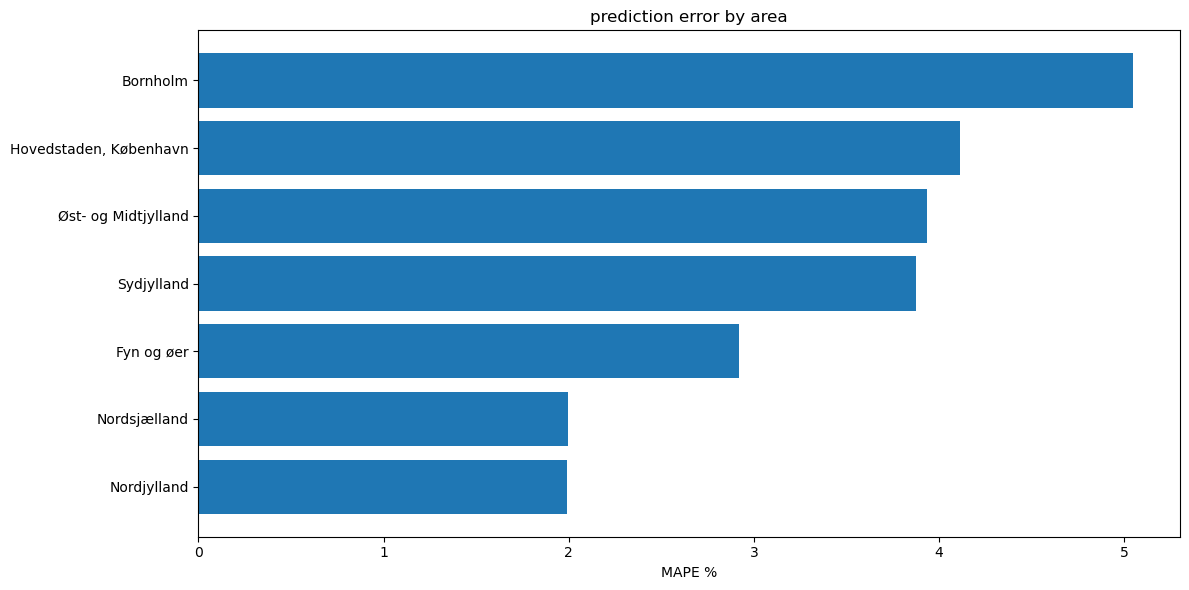

In [3]:
# testing xgboost with best params on holdout data by area
import numpy as np
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler
from matplotlib import pyplot as plt
df = pd.read_csv('cleaned_data_harshertest.csv')

df_clean = df.drop(columns=['dato'])

def mape(actual, pred):
    return np.mean(np.abs((actual - pred) / actual)) * 100

for col in df_clean.select_dtypes(include=['float', 'float64']).columns:
    df_clean = df_clean[~np.isinf(df_clean[col])]

# simple split - last 2% for testing
test_size = int(0.1 * len(df_clean))
train_data = df_clean.iloc[:-test_size]
test_data = df_clean.iloc[-test_size:]

print(f"train: {len(train_data):,}, test: {len(test_data):,}")

# prep the data
X_train = train_data.drop('købesum', axis=1)
y_train = train_data['købesum']
X_test = test_data.drop('købesum', axis=1)
y_test = test_data['købesum']

# scale it
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# train with best params
model = XGBRegressor(
    n_estimators=300,
    learning_rate=1, 
    max_depth=9,
    random_state=42
)

model.fit(X_train_scaled, y_train)
preds = model.predict(X_test_scaled)

print(f"overall mape: {mape(y_test, preds):.1f}%")

# by area
area_cols = [col for col in test_data.columns if 'område_' in col]

# quick plot
results = []
for col in area_cols:
    area_data = test_data[test_data[col] == 1]
    if len(area_data) > 5:
        area_name = col.replace('område_', '')
        area_actual = y_test[test_data[col] == 1]
        area_preds = preds[test_data[col] == 1]
        area_mape = mape(area_actual, area_preds)
        results.append([area_name, area_mape, len(area_data)])

results_df = pd.DataFrame(results, columns=['area', 'mape', 'count'])
results_df = results_df.sort_values('mape')

plt.figure(figsize=(12, 6))
plt.barh(results_df['area'], results_df['mape'])
plt.xlabel('MAPE %')
plt.title('prediction error by area')
plt.tight_layout()
plt.show()